In [7]:
import os

import cv2
import matplotlib.pyplot as plt
import torch
from PIL import Image
from matplotlib.patches import Rectangle
from torch.utils.data import DataLoader
from data_preprocessing import FlagOnGroundDataset
from torchvision import transforms
from models import load_model_retinanet
from training import RetinaNetTrainer

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device

device(type='cpu')

In [8]:
collab = False
if collab:
    from google.colab import drive

    drive.mount('/content/drive')
    folder_path = 'drive/MyDrive/ai_data/data'
else:
    folder_path = '../data'

checkpoint_in_path = None  # os.path.join(folder_path, 'checkpoints/retinanet_main.pth') 
checkpoint_out_path = os.path.join(folder_path, 'checkpoints/retinanet_demo.pth')

flags_path = os.path.join(folder_path, 'flags/')
desert_path = os.path.join(folder_path, 'desert/')

In [9]:
dataset = FlagOnGroundDataset(flags_path, desert_path, device, True)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

In [10]:
model = load_model_retinanet(folder_path + '/checkpoints/retinanet_main.pth')

In [11]:
trainer = RetinaNetTrainer(model)
trainer.train_epochs(dataloader, checkpoint_out_path, 100)

here


KeyboardInterrupt: 

In [12]:
model.eval()

RetinaNet(
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu): ReLU(inplace=True)
          (downsample): Sequential(
            (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): FrozenBatchNorm2d(256, e

tensor([], grad_fn=<IndexBackward0>)


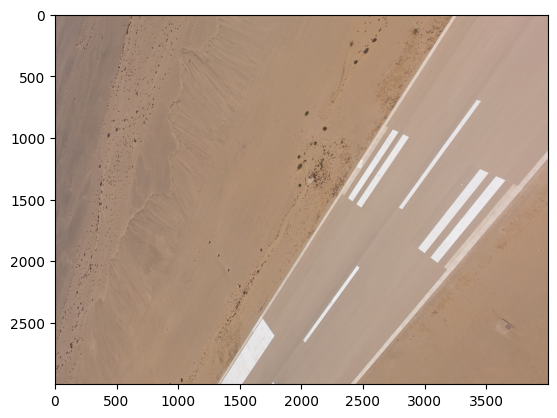

In [21]:
img = cv2.cvtColor(cv2.imread('./data/test/base (21).JPG'), cv2.COLOR_BGR2RGB)
img_t = transforms.ToTensor()(img)
# img = img_t = dataset[20][0]
result = model(img_t.unsqueeze(0))[0]
# img_t = transforms.ToTensor()(img)
boxes, scores = result['boxes'], result['scores']

print(scores)
if len(boxes) > 0:
    x1, y1, x2, y2 = boxes[0]
    x1 = x1.item()
    y1 = y1.item()
    x2 = x2.item()
    y2 = y2.item()

    ax = plt.gca()
    print(x1, y1, x2, y2)
    rect = Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)

plt.imshow(img_t.permute(1, 2, 0))

In [15]:
# Define the transformations, including resizing to 256x256 and converting to tensor
to_tensor = transforms.Compose([
    transforms.Resize((256, 256)),  # Resize to 256x256
    transforms.ToTensor()
])

input_video_path = folder_path + '/test/vid2.MP4'
output_video_path = folder_path + '/test/vid2_output.mp4'

cap = cv2.VideoCapture(input_video_path)

# Set up the video writer for the output
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out_fps = cap.get(cv2.CAP_PROP_FPS)
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter(output_video_path, fourcc, out_fps, (frame_width, frame_height))

# Calculate frames to skip
frames_to_skip = int(out_fps)  # Number of frames in 1 second

# Get total frame count for progress tracking
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Set the model to evaluation mode
model.eval()

while cap.isOpened():
    current_frame = int(cap.get(cv2.CAP_PROP_POS_FRAMES))
    ret, frame = cap.read()
    if not ret:
        break

    # Convert the frame to a PIL image and apply transformations
    pil_image = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    image_tensor = to_tensor(pil_image).unsqueeze(0)

    # Get predictions from the model
    with torch.no_grad():
        predictions = model(image_tensor)[0]

    # Extract bounding boxes and confidence scores
    boxes = predictions['boxes']
    scores = predictions['scores']

    # Process each bounding box and score
    for i, box in enumerate(boxes):
        confidence = scores[i].item()
        
        # Set the color based on confidence
        if confidence < 0.25:
            color = (0, 0, 255)  # Red for low confidence
        elif confidence < 0.6:
            color = (0, 255, 255)  # Yellow for medium confidence
        else:
            color = (0, 255, 0)  # Green for high confidence

        # Draw the bounding box if confidence threshold is met
        x1, y1, x2, y2 = box.int().tolist()
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

        # Draw confidence text with larger font size
        text = f'{confidence:.2f}'
        font_scale = 0.8  # Larger font scale
        thickness = 2
        (text_width, text_height), baseline = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness)
        cv2.rectangle(frame, (x1, y1 - text_height - baseline), (x1 + text_width, y1), color, -1)
        cv2.putText(frame, text, (x1, y1 - baseline), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0, 0, 0), thickness)

    # Write the frame to the output video
    out.write(frame)

    # Calculate and print progress percentage
    progress_percentage = (current_frame / total_frames) * 100
    print(f'Progress: {progress_percentage:.2f}%')

    # Skip frames to move 1 second forward
    cap.set(cv2.CAP_PROP_POS_FRAMES, current_frame + frames_to_skip)

# Release resources
cap.release()
out.release()
cv2.destroyAllWindows()


Progress: 0.00%
Progress: 2.48%
Progress: 4.97%
Progress: 7.45%
Progress: 9.94%
Progress: 12.42%
Progress: 14.90%
Progress: 17.39%
Progress: 19.87%
Progress: 22.35%
Progress: 24.84%
Progress: 27.32%
Progress: 29.81%
Progress: 32.29%
Progress: 34.77%
Progress: 37.26%
Progress: 39.74%
Progress: 42.23%
Progress: 44.71%
Progress: 47.19%
Progress: 49.68%
Progress: 52.16%
Progress: 54.64%
Progress: 57.13%
Progress: 59.61%
Progress: 62.10%
Progress: 64.58%
Progress: 67.06%
Progress: 69.55%
Progress: 72.03%
Progress: 74.52%
Progress: 77.00%
Progress: 79.48%
Progress: 81.97%
Progress: 84.45%
Progress: 86.93%
Progress: 89.42%
Progress: 91.90%
Progress: 94.39%
Progress: 96.87%
Progress: 99.35%


error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:1295: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvDestroyAllWindows'


In [31]:
total_params = sum(p.numel() for p in model.parameters())

# Each parameter is usually a float32 (4 bytes)
param_size_in_bytes = total_params * 4  # Total size in bytes

# Convert to megabytes (1 MB = 1,048,576 bytes)
param_size_in_MB = param_size_in_bytes / (1024 ** 2)

print(f"Total model size: {param_size_in_MB:.2f} MB")

Total model size: 122.71 MB
